<div style="display:flex; align-items:flex-start; justify-content:space-between; gap:24px; border-bottom:3px solid #8f001a; padding-bottom:16px;">
  <div>
    <h1 style="margin-bottom:0.35em;">Exercise 2: Specific Context for an SPI Formula Bug</h1>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Faculty of Engineering, University of Ottawa</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;"><strong>Provided By:</strong></p>
    <p style="font-size:1.05em; margin:0.2em 0;">Professor Hossein Bonakdari</p>
    <p style="font-size:1.05em; margin:0.2em 0;">PhD Candidate Mohammad Hashtari</p>
  </div>
  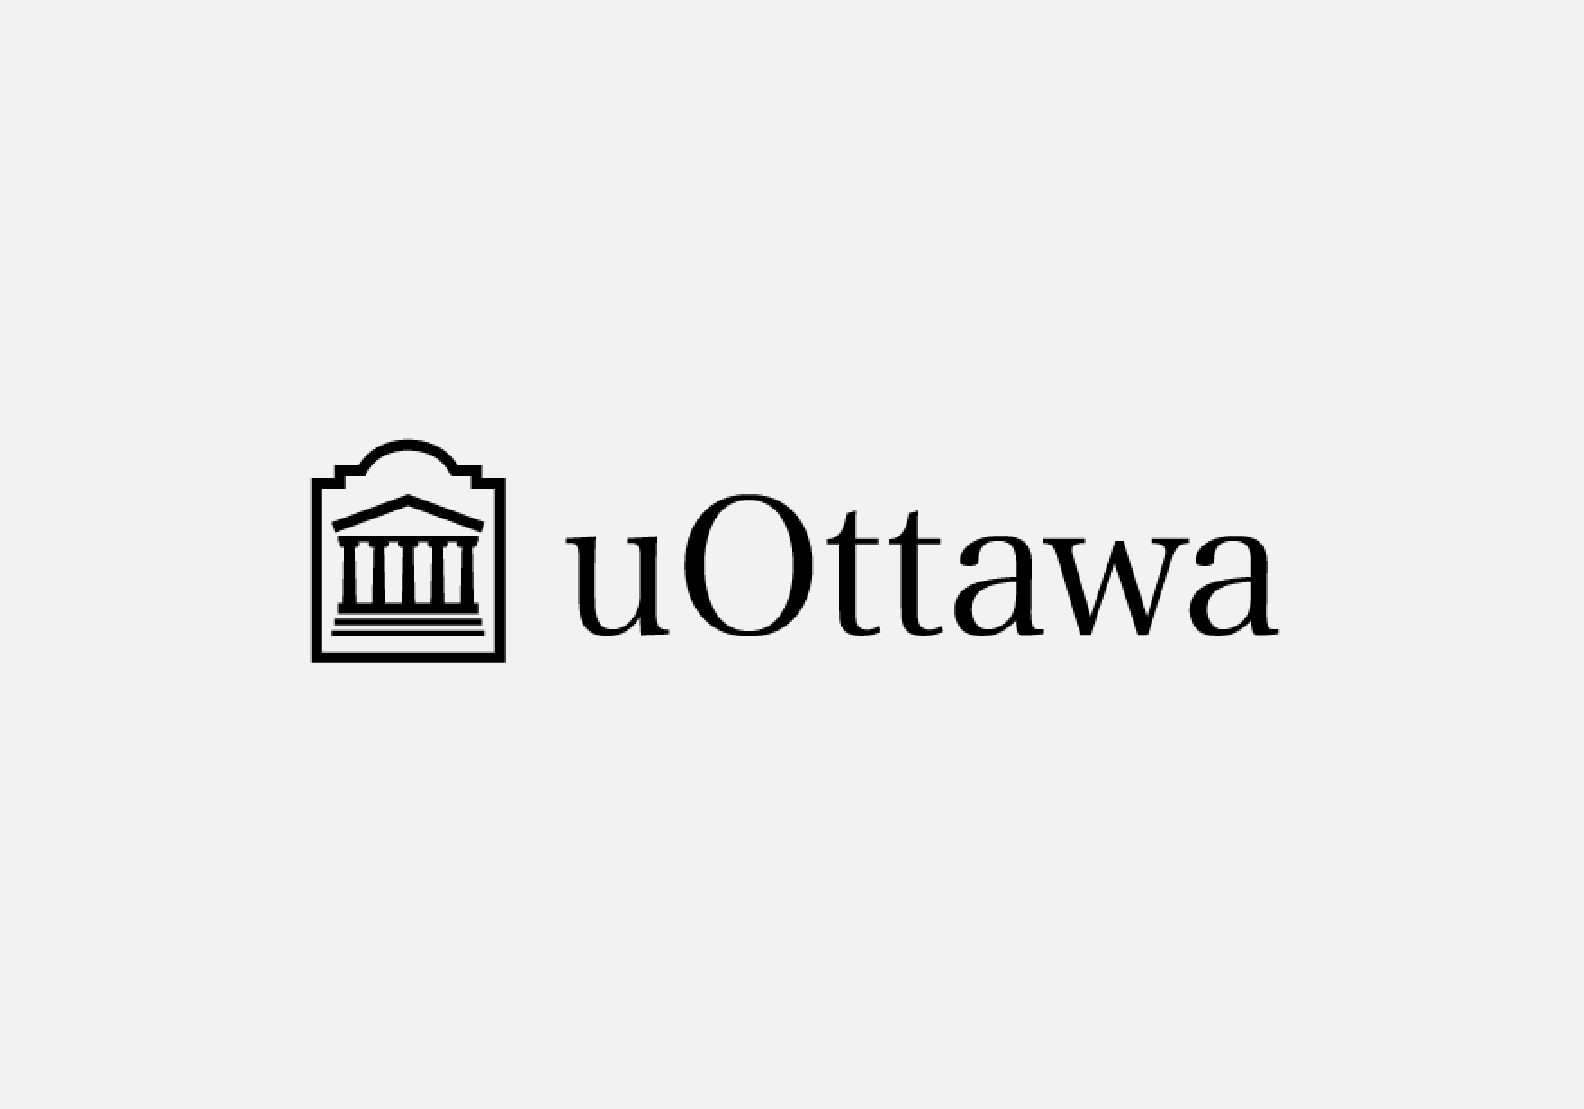
</div>

The SPI notebook uses a simplified Standardized Precipitation Index calculation to show how a bug report improves when it includes the formula, expected behavior, and a small failing example.

In [ ]:
# Browser package setup for JupyterLite. Safe to run in local Jupyter too.
import sys

if sys.platform == "emscripten":
    import piplite
    await piplite.install(["numpy", "pandas", "matplotlib", "scipy"])


## 1. Source Basis

The drought-index concept is based on the original SPI literature:

- McKee, T. B., Doesken, N. J., and Kleist, J. (1993). *The relationship of drought frequency and duration to time scales*. Proceedings of the 8th Conference on Applied Climatology, American Meteorological Society, 179-184. https://www.droughtmanagement.info/literature/AMS_Relationship_Drought_Frequency_Duration_Time_Scales_1993.pdf
- Edwards, D. C., and McKee, T. B. (1997). *Characteristics of 20th century drought in the United States at multiple time scales*. Colorado State University, Climatology Report 97-2. https://mountainscholar.org/handle/10217/170176

Scientific note: operational SPI is usually computed by accumulating precipitation over a selected time scale, fitting a probability distribution to the historical precipitation series, and transforming the cumulative probability to the standard normal scale. For the bug-report exercise, the notebook isolates a simpler standardization property: a precipitation value equal to the baseline mean should have a standardized anomaly of zero.

## 2. Learning Goal

A vague bug report makes the assistant search blindly. A specific bug report gives the assistant five useful anchors:

1. Symptom
2. File or cell location
3. Function name
4. Failing test or expected property
5. Verification instruction

Hydrology target: fix a formula where `mean` and `std` are swapped in a simplified SPI-style standardization.

## 3. Libraries

The notebook uses `numpy`, `pandas`, and `matplotlib` for a compact reproducible demonstration.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## 4. Sample Monthly Precipitation Series

The sample data are fictional monthly precipitation totals in millimetres. A value close to the historical mean should produce a standardized anomaly near zero.

In [ ]:
precip_mm = np.array([50.0, 80.0, 60.0, 70.0, 90.0, 40.0, 75.0, 55.0, 67.0, 83.0])

precip_df = pd.DataFrame({
    "month_id": np.arange(1, len(precip_mm) + 1),
    "precipitation_mm": precip_mm,
})

precip_df

In [ ]:
mean_precip = precip_df["precipitation_mm"].mean()

fig, ax = plt.subplots()
ax.bar(precip_df["month_id"], precip_df["precipitation_mm"], color="#1f6f8b")
ax.axhline(mean_precip, color="#d9480f", linestyle="--", linewidth=1.5, label=f"Mean = {mean_precip:.1f} mm")
ax.set_title("Fictional Monthly Precipitation Totals")
ax.set_xlabel("Month index")
ax.set_ylabel("Precipitation (mm)")
ax.legend()
plt.show()

## 5. Existing Buggy Function

The intended simplified formula is:

```text
standardized anomaly = (P - mean(P)) / std(P)
```

The buggy function below swaps the mean and standard deviation.

In [ ]:
def compute_spi_buggy(precipitation):
    """Buggy simplified SPI-style standardization."""
    p = np.asarray(precipitation, dtype=float)
    mean = p.mean()
    std = p.std(ddof=1)

    if std == 0:
        return np.zeros_like(p)

    return (p - std) / mean

## 6. Symptom

A month near the mean should have a value near zero. The buggy function gives a large positive value instead.

In [ ]:
spi_buggy = compute_spi_buggy(precip_mm)
mean_index = int(np.argmin(np.abs(precip_mm - mean_precip)))

buggy_result = pd.DataFrame({
    "precipitation_mm": precip_mm,
    "buggy_spi": spi_buggy,
})

buggy_result.iloc[mean_index:mean_index + 1]

In [ ]:
try:
    assert abs(spi_buggy[mean_index]) < 0.05
    bug_check = "Unexpected pass"
except AssertionError:
    bug_check = (
        f"Expected failure: precipitation near the mean is {precip_mm[mean_index]:.1f} mm, "
        f"but the buggy value is {spi_buggy[mean_index]:.3f}."
    )

bug_check

## 7. Before and After Prompts

Weak prompt:

```text
Fix the SPI calculation bug.
```

Specific prompt:

```text
The simplified SPI calculation gives large anomalies for precipitation values near the mean.
The bug is in compute_spi_buggy().
The check abs(spi[mean_index]) < 0.05 fails for the month nearest the baseline mean.
Fix the root cause in the formula: subtract the mean and divide by the sample standard deviation.
After fixing, verify that the mean-near month is near zero, wet months are positive, dry months are negative, and a constant series returns zero.
```

The second prompt gives the assistant the symptom, location, evidence, constraint, and verification target.

## 8. Concept Graph

The purpose of specific context is to reduce guessing.

In [ ]:
fig, ax = plt.subplots(figsize=(8.5, 6.2))
ax.set_axis_off()

steps = [
    ('Symptom', 'Normal rainfall gives a large anomaly'),
    ('Location', 'Name the function or cell'),
    ('Evidence', 'Show the failing check'),
    ('Constraint', 'Fix the root formula'),
    ('Verify', 'Run hydrology checks'),
]

x = 0.12
width = 0.76
height = 0.105
if len(steps) == 1:
    y_positions = [0.50]
else:
    y_positions = [0.78 - i * (0.66 / (len(steps) - 1)) for i in range(len(steps))]

for i, ((step_title, subtitle), y) in enumerate(zip(steps, y_positions)):
    box = FancyBboxPatch(
        (x, y), width, height,
        boxstyle="round,pad=0.018,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="#264653",
        facecolor="#edf6f9",
        transform=ax.transAxes,
    )
    ax.add_patch(box)
    ax.text(x + 0.035, y + height * 0.64, step_title, ha="left", va="center", fontsize=11, weight="bold", transform=ax.transAxes)
    ax.text(x + 0.035, y + height * 0.30, subtitle, ha="left", va="center", fontsize=9, transform=ax.transAxes)
    if i < len(steps) - 1:
        next_y = y_positions[i + 1]
        ax.annotate(
            "", xy=(0.50, next_y + height + 0.015), xytext=(0.50, y - 0.015),
            arrowprops={"arrowstyle": "->", "lw": 1.4, "color": "#264653"},
            xycoords=ax.transAxes,
        )

ax.set_title('Anatomy of a Specific Bug Report', pad=12)
plt.show()

## 9. Correct Implementation

The corrected function subtracts the precipitation mean and divides by the sample standard deviation. The constant-series guard prevents division by zero.

In [ ]:
def compute_spi(precipitation):
    """Compute a simplified SPI-style standardized precipitation anomaly."""
    p = np.asarray(precipitation, dtype=float)
    mean = p.mean()
    std = p.std(ddof=1)

    if std == 0:
        return np.zeros_like(p)

    return (p - mean) / std


spi = compute_spi(precip_mm)
pd.DataFrame({
    "precipitation_mm": precip_mm,
    "spi_simplified": spi,
})

## 10. Verification Tests

The tests check the formula and the hydrological sign convention.

In [ ]:
expected_spi = (precip_mm - precip_mm.mean()) / precip_mm.std(ddof=1)

assert np.allclose(spi, expected_spi)
assert abs(spi[mean_index]) < 0.05
assert compute_spi(np.array([50.0, 55.0, 48.0, 52.0, 200.0]))[-1] > 1.0
assert compute_spi(np.array([50.0, 55.0, 48.0, 52.0, 5.0]))[-1] < -1.0
assert np.all(compute_spi(np.full(12, 60.0)) == 0.0)

print("All checks passed.")

## 11. Visual Comparison

The corrected values are centred around zero. The buggy values are shifted because the formula used the wrong quantities in the wrong places.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.4))
x = precip_df["month_id"].to_numpy()

ax.plot(x, spi_buggy, marker="o", color="#d9480f", label="Buggy formula")
ax.plot(x, spi, marker="o", color="#0b7285", label="Corrected formula")
ax.axhline(0, color="#222222", linewidth=1)
ax.set_title("Buggy versus Corrected Standardized Precipitation Values")
ax.set_xlabel("Month index")
ax.set_ylabel("Standardized precipitation anomaly")
ax.legend()
plt.show()

## 12. Hydrological Interpretation

The corrected simplified index has the expected sign behaviour: months wetter than the sample mean are positive and months drier than the sample mean are negative. A month near the mean has a value near zero. This is only a teaching-scale standardization, not a full operational SPI calculation, because it does not fit a precipitation probability distribution by calendar month and accumulation period.

## 13. Summary

- A vague bug report makes the assistant infer too much.
- A specific prompt identifies the symptom, location, evidence, constraint, and verification.
- The corrected simplified formula is `(P - mean(P)) / std(P)`.
- The hydrological check is simple: near-mean precipitation should give a near-zero standardized anomaly.

For real SPI applications, the distributional fitting step and accumulation time scale must be specified explicitly.